# Visualisierung der Prüfungsleistung von Schülern mit 3D-Flächen und Streudiagrammen (PROC G3D)

## Zusammenfassung

Dieses Notebook verwendet **PROC G3D**, um zu visualisieren, wie zwei Faktoren einer
unterrichtlichen Intervention gemeinsam die Ergebnisse von Schülern in einem
Bildungsanalyse-Szenario prägen. Ein vollständiges faktorielles Gitter erzeugt eine glatte
Antwort**fläche** vorhergesagter Prüfungsergebnisse über wöchentliche Lernstunden (0 bis 20)
und vorherigen Notendurchschnitt (0 bis 4), und eine synthetische Kohorte von 100 Schülern
wird als **3D-Streudiagramm**-Panels, aufgeteilt nach Leistungsstufe, dargestellt.

Die angepasste Fläche steigt von einem vorhergesagten Ergebnis von nahe 26 bei null
Lernstunden auf ein Maximum von nahe 99 und flacht ab, sobald die Lernstunden etwa 10
überschreiten — der abnehmende Grenzertrag, den das Modell abbildet. Die Schülerpanels
bestätigen das Muster auf individueller Ebene: die 20 Schüler mit *Auszeichnung* (jeder mit
85 Punkten oder mehr) sitzen in der Ecke mit hohem Notendurchschnitt und höherem Lernaufwand,
während sich die 33 *gefährdeten* Schüler in der Region mit geringem Aufwand und niedrigem
Notendurchschnitt konzentrieren. Eine mit WHERE gefilterte Ansicht dieser Ecke isoliert 35
Schüler, für die moderate Erhöhungen der Lernzeit den größten Grenznutzen bieten.

## Datenquellen

Alle Daten werden inline mit `call streaminit()` und `rand()` erzeugt — keine externen
Dateien oder Netzwerkzugriffe.

**`score_grid`** — vollständiges faktorielles Gitter, das die Antwortfläche erzeugt (eine
Zeile pro Zelle aus Lernstunden x vorherigem Notendurchschnitt, 99 Zeilen).

| Variable | Typ | Beschreibung |
|----------|------|-------------|
| `study_hours` | Num | Wöchentliche Selbstlernstunden, 0 bis 20 in Schritten von 2 (X-Achse) |
| `prior_gpa` | Num | Notendurchschnitt des Vorsemesters auf einer Skala von 0–4, 0 bis 4 in Schritten von 0,5 (Y-Achse) |
| `pred_score` | Num | Modelliertes Abschlussprüfungsergebnis 0–100 aus einem sättigenden Antwortmodell (Z-Achse) |

**`students`** — synthetische individuelle Schülerkohorte für das Streudiagramm (100 Zeilen).

| Variable | Typ | Beschreibung |
|----------|------|-------------|
| `student_id` | Num | Fortlaufende Schülerkennung |
| `study_hours` | Num | Beobachtete wöchentliche Lernstunden (X-Achse) |
| `prior_gpa` | Num | Beobachteter Notendurchschnitt des Vorsemesters (Y-Achse) |
| `exam_score` | Num | Beobachtetes Abschlussprüfungsergebnis 0–100 (Z-Achse) |
| `cohort` | Char | Einschreibungskohorte, `Fall` oder `Spring` |
| `band` | Char | Leistungsstufe: `Honors` (≥85), `Pass` (65–84), `AtRisk` (<65) |

Das Gitter ist bewusst auf 99 Zellen ausgelegt, sodass es den vollen Bereich von 0–20
Lernstunden und 0–4 Notendurchschnitt abdeckt, während es innerhalb der 100-Beobachtungs-
Grenze dieser Umgebung bleibt; ein 11x9-Gitter hält die Fläche glatt, ohne eine der beiden
Achsen zu beschneiden.

# Visualisierung der Prüfungsleistung von Schülern mit PROC G3D

Bildungsforscher wollen oft verstehen, wie zwei beeinflussbare Faktoren gemeinsam ein
Ergebnis antreiben. Hier fragen wir: *wie kombinieren sich wöchentliche Lernstunden und der
vorherige Notendurchschnitt eines Schülers, um die Leistung in der Abschlussprüfung zu
formen?*

Ein zweidimensionales Diagramm kann eine Interaktionsfläche nicht zeigen. **PROC G3D**
zeichnet echte dreidimensionale Grafiken aus Variablen in der Notation `y*x=z`, wobei X und
Y die horizontale Ebene aufspannen und Z vertikal ansteigt. Wir nutzen zwei seiner
Fähigkeiten:

- **PLOT** — eine kontinuierliche Antwort*fläche* über ein vollständiges Gitter der beiden
  Prädiktoren.
- **SCATTER** — einzelne Schüler, dargestellt als 3D-Symbole. Wir zeichnen ein Panel pro
  Leistungsstufe, jedes mit eigener Markierungsfarbe und -form, sodass die drei
  Ergebnisstufen leicht zu vergleichen sind.

Alles Folgende läuft auf inline erzeugten synthetischen Daten, sodass das Notebook
vollständig eigenständig ist.

## Schritt 1 — Das Gitter der Antwortfläche erzeugen

Ein G3D-Flächendiagramm benötigt ein einigermaßen vollständiges Gitter: es braucht
nicht-fehlende Z-Werte für mindestens die Hälfte der X-Y-Zellen. Wir garantieren ein
*vollständiges* Gitter, indem wir zwei `DO`-Schleifen über `study_hours` (0 bis 20 in
Schritten von 2) und `prior_gpa` (0 bis 4 in Schritten von 0,5) verschachteln — ein
11x9-Gitter aus 99 Zellen, das beide Achsen vollständig abdeckt.

Das vorhergesagte Ergebnis folgt einem plausiblen sättigenden Modell: der Ertrag aus dem
Lernen nimmt bei hohen Stunden ab, der vorherige Notendurchschnitt trägt annähernd linear
bei, und die beiden interagieren (ein starker Schüler wandelt Lernzeit effizienter in Punkte
um). Ein kleines reproduzierbares Rauschen aus `rand('NORMAL')` verhindert, dass die Fläche
perfekt analytisch aussieht. `call streaminit()` legt den Seed fest, sodass das Gitter
reproduzierbar ist.

In [1]:
DATEN score_grid;
   AUFRUFEN streaminit(20260531);
   AUSFÜHRUNG study_hours = 0 BIS 20 NACH 2;     /* 11 Werte: voller Bereich 0-20 */
      AUSFÜHRUNG prior_gpa = 0 BIS 4 NACH 0.5;   /* 9 Werte  -> 99 Gitterzellen */
         /* saettigender Ertrag der Lernstunden */
         effort = 40 * (1 - EXP(-study_hours / 6));
         /* vorherige Leistung und ein Interaktionsterm */
         BASE   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
         pred_score = 25 + effort + BASE + inter
                      + rand('NORMAL') * 1.5;
         WENN pred_score > 100 DANN pred_score = 100;
         WENN pred_score < 0   DANN pred_score = 0;
         AUSGABE;
      ENDE;
   ENDE;
   BEHALTEN study_hours prior_gpa pred_score;
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=score_grid n MIN mean MAX maxdec=1;
   VAR study_hours prior_gpa pred_score;
AUSFÜHREN;

                                                  The MEANS Procedure

 Variable           N     Minimum        Mean     Maximum
 --------------------------------------------------------
 study_hours       99         0.0        10.0        20.0
 prior_gpa         99         0.0         2.0         4.0
 pred_score        99        25.7        70.0        98.7
 --------------------------------------------------------




NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Schritt 2 — Die grundlegende Antwortfläche zeichnen

Mit einem vollständigen Gitter zeichnet der einfachste Aufruf die Fläche mit den
Standardeinstellungen der Prozedur. Die Syntax `PLOT y*x=z` bildet `prior_gpa` auf die
Y-Achse, `study_hours` auf die X-Achse und das vorhergesagte Ergebnis auf die vertikale
Z-Achse ab.

Wir beschriften die Achsen mit einer `LABEL`-Anweisung und setzen Titel und eine Fußnote mit
den globalen `TITLE`/`FOOTNOTE`-Anweisungen, damit die Grafik sauber zu lesen ist.

                                     Vorhergesagte Abschlussprüfungs-Ergebnisfläche                                     
                         Effekt von wöchentlichen Lernstunden und vorherigem Notendurchschnitt                          

PROC G3D Output
Data: score_grid

Variables: Wöchentliche Lernstunden, Vorheriger Notendurchschnitt, Vorhergesagtes Prüfungsergebnis

 Wöchentliche Lernstunden  Vorheriger Notendurchschnitt   Vorhergesagtes Prüfungsergebnis
-------------------------  ----------------------------  --------------------------------
                        0                             0                     25.7031536911
                        0                           0.5                     28.9516502743
                        0                             1                     32.3400787822
                        0                           1.5                     36.8265757618
                        0                             2                     40.7806


NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to Vorhergesagte Abschlussprüfungs-Ergebnisfläche.
NOTE: Option TITLE2 changed to Effekt von wöchentlichen Lernstunden und vorherigem Notendurchschnitt.
NOTE: Option FOOTNOTE changed to Synthetische Bildungsanalyse-Daten .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


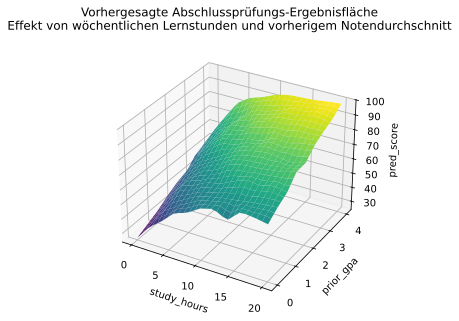

In [2]:
GOPTIONS reset=GLOBAL BORDER;

TITEL 'Vorhergesagte Abschlussprüfungs-Ergebnisfläche';
title2 'Effekt von wöchentlichen Lernstunden und vorherigem Notendurchschnitt';
footnote j=r 'Synthetische Bildungsanalyse-Daten ';

PROZEDUR g3d DATEN=score_grid;
   PLOT prior_gpa*study_hours=pred_score;
   BEZEICHNUNG study_hours = 'Wöchentliche Lernstunden'
         prior_gpa   = 'Vorheriger Notendurchschnitt'
         pred_score  = 'Vorhergesagtes Prüfungsergebnis';
AUSFÜHREN;
QUIT;

## Schritt 3 — Die Fläche mit Ansichts- und Achsenoptionen verfeinern

Ein paar Optionen machen die Fläche wesentlich lesbarer:

- **ROTATE=** und **TILT=** legen den Betrachtungswinkel fest (Grad um die Z-Achse und
  Neigung zum Betrachter).
- **XYTYPE=2** zeichnet Flächenlinien parallel zur Y-Achse und betont, wie das Ergebnis mit
  den Lernstunden steigt.
- **SIDE** fügt eine Seitenwand für eine solide, plastische Optik hinzu.
- **GRID** fügt Referenzlinien an den Hauptteilstrichen hinzu.
- **ZMIN=/ZMAX=** und die Familie **ZTICKNUM=** legen die Ergebnisachse auf den vollen
  Bereich 0–100 fest, sodass die Fläche nicht optisch übertrieben wirkt, während
  **XTICKNUM=/YTICKNUM=** die Teilstriche der Grundebene steuern.
- **NAME=** und **DESCRIPTION=** beschriften die Grafik im Ausgabekatalog.

                                Vorhergesagte Prüfungsergebnisfläche (gestylte Ansicht)                                 
                                          Gedreht, geneigt und achsenskaliert                                           

PROC G3D Output
Data: score_grid

Variables: Wöchentliche Lernstunden, Vorheriger Notendurchschnitt, Vorhergesagtes Prüfungsergebnis

 Wöchentliche Lernstunden  Vorheriger Notendurchschnitt   Vorhergesagtes Prüfungsergebnis
-------------------------  ----------------------------  --------------------------------
                        0                             0                     25.7031536911
                        0                           0.5                     28.9516502743
                        0                             1                     32.3400787822
                        0                           1.5                     36.8265757618
                        0                             2                     40.7806


NOTE: Option TITLE changed to Vorhergesagte Prüfungsergebnisfläche (gestylte Ansicht).
NOTE: Option TITLE2 changed to Gedreht, geneigt und achsenskaliert.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


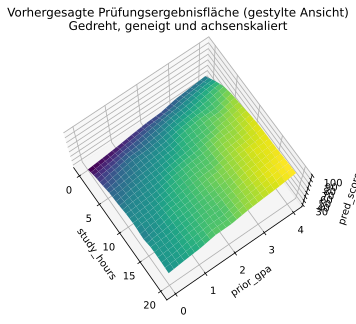

In [3]:
TITEL 'Vorhergesagte Prüfungsergebnisfläche (gestylte Ansicht)';
title2 'Gedreht, geneigt und achsenskaliert';

PROZEDUR g3d DATEN=score_grid;
   PLOT prior_gpa*study_hours=pred_score /
        ROTATE=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="Gestylte Antwortfläche des Prüfungsergebnisses";
   BEZEICHNUNG study_hours = 'Wöchentliche Lernstunden'
         prior_gpa   = 'Vorheriger Notendurchschnitt'
         pred_score  = 'Vorhergesagtes Prüfungsergebnis';
AUSFÜHREN;
QUIT;

## Schritt 4 — Die Fläche aus mehreren Blickwinkeln vergleichen

Da eine 3D-Fläche Struktur hinter ihren eigenen Erhebungen verbergen kann, hilft es, dieselbe
Fläche aus mehr als einer Drehung zu rendern. Hier geben wir drei PROC-G3D-Schritte aus, die
eine feste Neigung teilen, aber den Winkel **ROTATE=** durch 30, 90 und 150 Grad schrittweise
verändern, sodass der Grat von vorne, von der Seite und von hinten betrachtet werden kann.

                                                     Antwortfläche                                                      
                                             ROTATE = 30 bei fester Neigung                                             

PROC G3D Output
Data: score_grid

Variables: Wöchentliche Lernstunden, Vorheriger Notendurchschnitt, Vorhergesagtes Prüfungsergebnis

 Wöchentliche Lernstunden  Vorheriger Notendurchschnitt   Vorhergesagtes Prüfungsergebnis
-------------------------  ----------------------------  --------------------------------
                        0                             0                     25.7031536911
                        0                           0.5                     28.9516502743
                        0                             1                     32.3400787822
                        0                           1.5                     36.8265757618
                        0                             2                     40.7806


NOTE: Option TITLE changed to Antwortfläche.
NOTE: Option TITLE2 changed to ROTATE = 30 bei fester Neigung.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to Antwortfläche.
NOTE: Option TITLE2 changed to ROTATE = 90 bei fester Neigung.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to Antwortfläche.
NOTE: Option TITLE2 changed to ROTATE = 150 bei fester Neigung.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


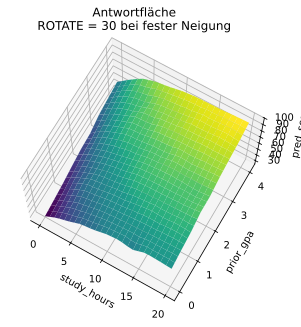

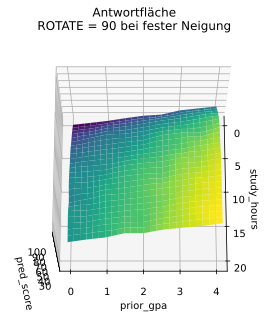

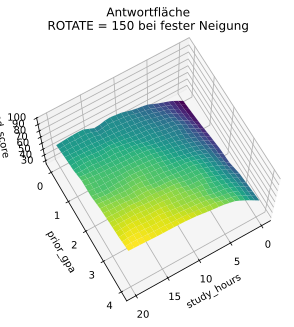

In [4]:
%macro angle(deg);
   TITEL 'Antwortfläche';
   title2 "ROTATE = &deg bei fester Neigung";
   PROZEDUR g3d DATEN=score_grid;
      PLOT prior_gpa*study_hours=pred_score /
           ROTATE=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      BEZEICHNUNG study_hours = 'Wöchentliche Lernstunden'
            prior_gpa   = 'Vorheriger Notendurchschnitt'
            pred_score  = 'Vorhergesagtes Prüfungsergebnis';
   AUSFÜHREN;
   QUIT;
%mend;

%angle(30);
%angle(90);
%angle(150);

## Schritt 5 — Eine synthetische Schülerkohorte erzeugen

Die Fläche ist ein Modell; reale Schüler streuen um sie herum. Wir simulieren nun 100
einzelne Schüler aus zwei Einschreibungskohorten (`Fall`, `Spring`). Jeder Schüler hat
beobachtete Lernstunden, einen vorherigen Notendurchschnitt und ein verrauschtes,
realisiertes Prüfungsergebnis, das aus derselben Antwortlogik plus größerer individueller
Variation erzeugt wird.

Wir leiten dann eine Leistungs**stufe** (`band`) aus dem Prüfungsergebnis ab: `Honors` (85
oder mehr), `Pass` (65 bis 84) und `AtRisk` (unter 65). Die PROC-FREQ-Kreuztabelle unten
zeigt, wie sich die Stufen über die beiden Kohorten verteilen. `rand('UNIFORM')` und
`rand('NORMAL')` liefern die Zufälligkeit; der Seed hält es reproduzierbar.

                                                     Antwortfläche                                                      
                                            ROTATE = 150 bei fester Neigung                                             

                                                   The FREQ Procedure

                               Cumulative
Leistungsstufe    Frequency    Frequency
--------------------------------------------
Auszeichnung             20           20
Bestanden                47           67
Gefährdet                33          100

Table of Einschreibungskohorte by Leistungsstufe

Einschreibungskohorte |Auszeichnung |   Bestanden |   Gefährdet |        Total
----------------------+-------------+-------------+-------------+-------------
Frühjahr              |          14 |          27 |          18 |           59
----------------------+-------------+-------------+-------------+-------------
Herbst                |           6 |          20 |          15 |   


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


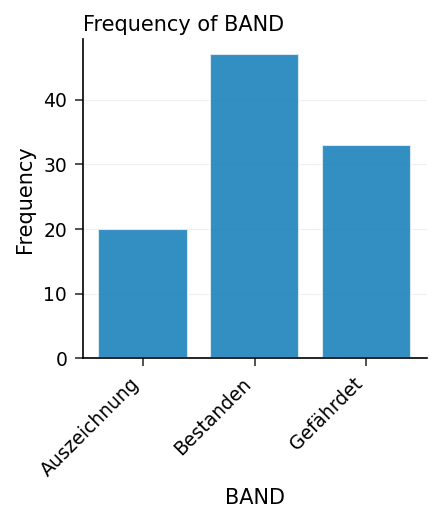

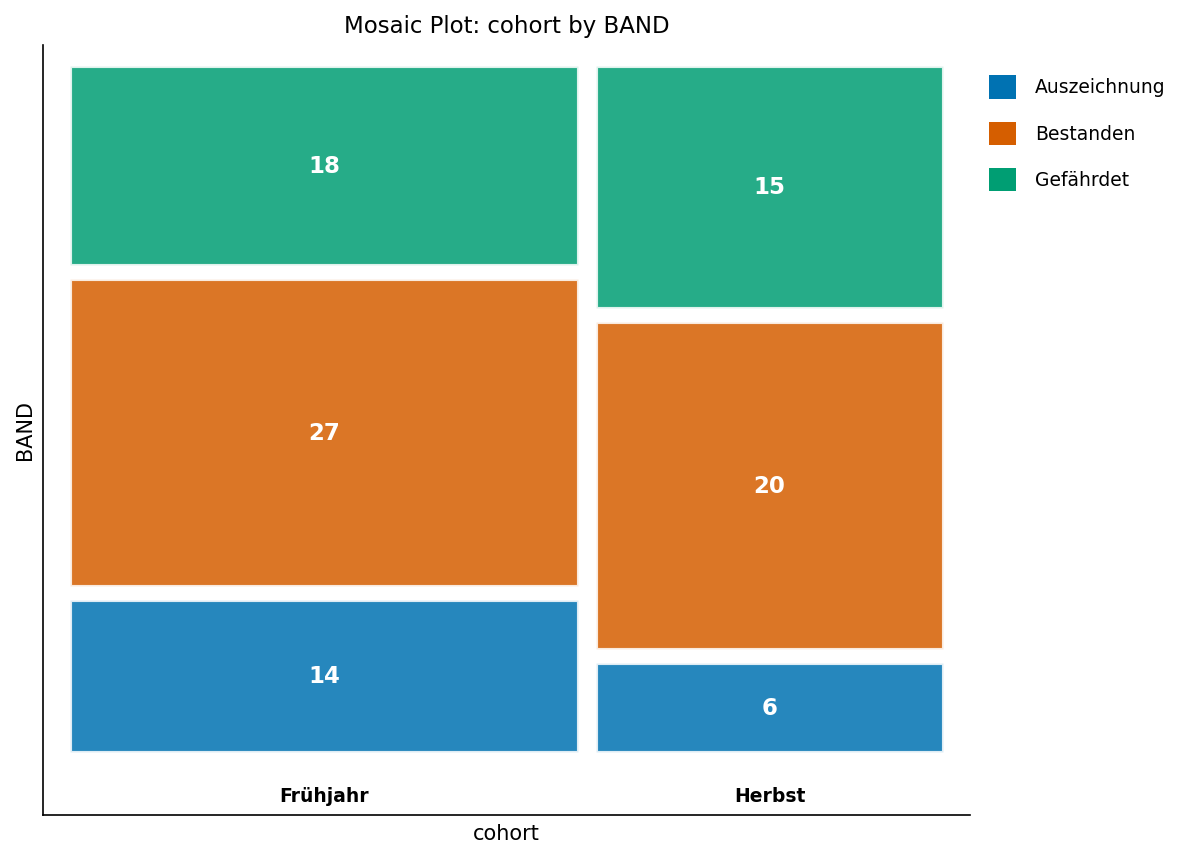

In [5]:
DATEN students;
   AUFRUFEN streaminit(99001);
   LÄNGE cohort $10 BAND $14;
   AUSFÜHRUNG student_id = 1 BIS 100;
      WENN rand('UNIFORM') < 0.5 DANN cohort = 'Herbst';
      SONST cohort = 'Frühjahr';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - EXP(-study_hours / 6));
      BASE   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
      exam_score = 25 + effort + BASE + inter
                   + rand('NORMAL') * 7;
      WENN exam_score > 100 DANN exam_score = 100;
      WENN exam_score < 0   DANN exam_score = 0;

      WENN exam_score >= 85 DANN BAND = 'Auszeichnung';
      SONST WENN exam_score >= 65 DANN BAND = 'Bestanden';
      SONST BAND = 'Gefährdet';

      AUSGABE;
   ENDE;
   BEHALTEN student_id cohort study_hours prior_gpa exam_score BAND;
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=students;
   TABLES BAND cohort*BAND / nocol nopercent;
   BEZEICHNUNG cohort = "Einschreibungskohorte" BAND = "Leistungsstufe";
AUSFÜHREN;

## Schritt 6 — Schüler als 3D-Streudiagramm-Panels nach Leistungsstufe darstellen

Die **SCATTER**-Anweisung platziert jeden Schüler als 3D-Symbol. Damit die drei
Leistungsstufen leicht lesbar sind, zeichnen wir ein Panel pro Stufe, jedes gefiltert mit
**WHERE** und mit eigenem, literalem **COLOR=** und **SHAPE=**: grüne Rauten
(`SHAPE=diamond`) für *Auszeichnung*, blaue Markierungen (`SHAPE=club`) für *Bestanden* und
rote Markierungen (`SHAPE=spade`) für *Gefährdet*. **SIZE=** vergrößert die Markierungen,
**GRID** fügt Bodenreferenzlinien hinzu, **NONEEDLE** entfernt die vertikalen Falllinien,
und **ZMIN=/ZMAX=** halten jedes Panel auf derselben Ergebnisachse 0–100, sodass die
drei Ansichten direkt vergleichbar sind.

Jede Stufe erhält ihren eigenen PROC-G3D-Schritt, damit ihr WHERE-Filter sauber greift und
der Markierungsstil eindeutig ist.

                                                Schüler mit Auszeichnung                                                
                                            Prüfungsergebnis 85 und darüber                                             

PROC G3D Output
Data: students

Variables: student_id, cohort, Wöchentliche Lernstunden, Vorheriger Notendurchschnitt, Prüfungsergebnis, BAND

student_id      cohort   Wöchentliche Lernstunden  Vorheriger Notendurchschnitt   Prüfungsergebnis        BAND
----------  ----------  -------------------------  ----------------------------  -----------------  ----------
         2    Frühjahr              19.2134883194                  2.6467742616      90.3663886999  Auszeichnung
         5    Frühjahr              15.5520919174                  2.7102003827      94.9419468332  Auszeichnung
        10    Frühjahr              14.2302640951                  3.8791496428                100  Auszeichnung
        17    Frühjahr              13.7403346635    


NOTE: Option FOOTNOTE changed to Aus einer Kohorte von 100 synthetischen Schülern .
NOTE: Option TITLE changed to Schüler mit Auszeichnung.
NOTE: Option TITLE2 changed to Prüfungsergebnis 85 und darüber.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to Schüler mit Bestanden.
NOTE: Option TITLE2 changed to Prüfungsergebnis 65 bis 84.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to Gefährdete Schüler.
NOTE: Option TITLE2 changed to Prüfungsergebnis unter 65.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


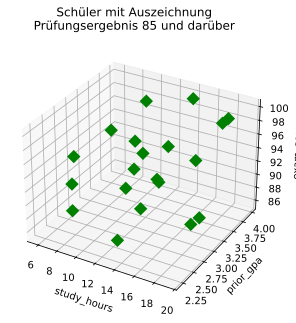

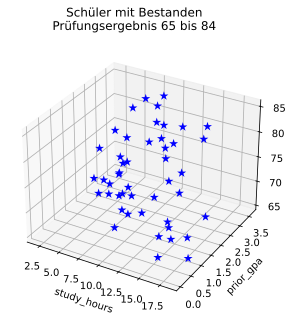

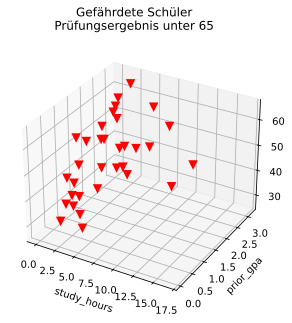

In [6]:
footnote j=r 'Aus einer Kohorte von 100 synthetischen Schülern ';

/* Auszeichnung (exam_score >= 85): gruene Rauten */
TITEL 'Schüler mit Auszeichnung';
title2 'Prüfungsergebnis 85 und darüber';
PROZEDUR g3d DATEN=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="Schüler mit Auszeichnung";
   WO BAND = 'Auszeichnung';
   BEZEICHNUNG study_hours = 'Wöchentliche Lernstunden'
         prior_gpa   = 'Vorheriger Notendurchschnitt'
         exam_score  = 'Prüfungsergebnis';
AUSFÜHREN;
QUIT;

/* Bestanden (65 <= exam_score < 85): blaue Kleeblaetter */
TITEL 'Schüler mit Bestanden';
title2 'Prüfungsergebnis 65 bis 84';
PROZEDUR g3d DATEN=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="Schüler mit Bestanden";
   WO BAND = 'Bestanden';
   BEZEICHNUNG study_hours = 'Wöchentliche Lernstunden'
         prior_gpa   = 'Vorheriger Notendurchschnitt'
         exam_score  = 'Prüfungsergebnis';
AUSFÜHREN;
QUIT;

/* Gefaehrdet (exam_score < 65): rote Pik-Symbole */
TITEL 'Gefährdete Schüler';
title2 'Prüfungsergebnis unter 65';
PROZEDUR g3d DATEN=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="Gefährdete Schüler";
   WO BAND = 'Gefährdet';
   BEZEICHNUNG study_hours = 'Wöchentliche Lernstunden'
         prior_gpa   = 'Vorheriger Notendurchschnitt'
         exam_score  = 'Prüfungsergebnis';
AUSFÜHREN;
QUIT;

## Schritt 7 — Separate Streudiagramme je Einschreibungskohorte (BY-Gruppe)

Programmleiter benötigen oft dieselbe Ansicht, aufgeteilt nach Kohorte. Die
**BY**-Anweisung erzeugt ein Streudiagramm pro Kohorte. G3D erwartet, dass BY-Gruppendaten
sortiert sind, daher sortieren wir zuerst mit PROC SORT. Jede Kohorte erhält dann ihr
eigenes beschriftetes 3D-Streudiagramm auf einer gemeinsamen Ergebnisachse 0–100, sodass die
Fall- und Spring-Verteilungen leicht nebeneinander verglichen werden können.

                                     Prüfungsergebnisse nach Einschreibungskohorte                                      
                                  Ein 3D-Streudiagramm pro Kohorte (Herbst, Frühjahr)                                   

PROC G3D Output
Data: students_sorted

Variables: student_id, cohort, Wöchentliche Lernstunden, Vorheriger Notendurchschnitt, Prüfungsergebnis, BAND

student_id      cohort   Wöchentliche Lernstunden  Vorheriger Notendurchschnitt   Prüfungsergebnis        BAND
----------  ----------  -------------------------  ----------------------------  -----------------  ----------
        53    Frühjahr              10.7875369915                  3.0789706431      76.6136428341   Bestanden
       100    Frühjahr              10.7782420031                  3.5469548845                100  Auszeichnung
         4    Frühjahr               8.3587240648                  1.1475897699      65.4995231815   Bestanden
         5    Frühjahr              15.5520919174 


NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Prüfungsergebnisse nach Einschreibungskohorte.
NOTE: Option TITLE2 changed to Ein 3D-Streudiagramm pro Kohorte (Herbst, Frühjahr).
NOTE: Option FOOTNOTE changed to Ein Panel pro Kohorte .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


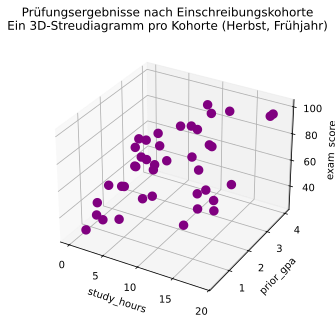

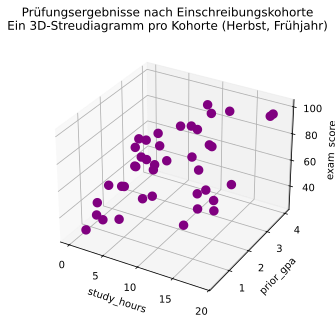

In [7]:
PROZEDUR SORTIEREN DATEN=students out=students_sorted;
   NACH cohort;
AUSFÜHREN;

TITEL 'Prüfungsergebnisse nach Einschreibungskohorte';
title2 'Ein 3D-Streudiagramm pro Kohorte (Herbst, Frühjahr)';
footnote j=r 'Ein Panel pro Kohorte ';

PROZEDUR g3d DATEN=students_sorted;
   NACH cohort;
   SCATTER prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   BEZEICHNUNG study_hours = 'Wöchentliche Lernstunden'
         prior_gpa   = 'Vorheriger Notendurchschnitt'
         exam_score  = 'Prüfungsergebnis';
AUSFÜHREN;
QUIT;

## Schritt 8 — Mit WHERE auf die gefährdete Region fokussieren

Für die Interventionsplanung ist die handlungsrelevanteste Ansicht die untere linke Ecke der
Fläche: Schüler mit sowohl moderater Lernzeit (8 Stunden oder weniger) als auch niedrigerem
vorherigem Notendurchschnitt (2,5 oder darunter). Die **WHERE**-Anweisung filtert das
Streudiagramm auf diese Region, bevor gezeichnet wird. Die Liste zeigt, dass diese Ecke 35
der 100 Schüler enthält — 22 von ihnen bereits *gefährdet* —, sodass Berater genau sehen
können, welche kämpfenden Schüler am weitesten unter den Erwartungen liegen.

                  Interventionsfokus: Schüler mit geringerem Aufwand und niedrigerem Notendurchschnitt                  
                                         study_hours <= 8 and prior_gpa <= 2.5                                          

PROC G3D Output
Data: students

Variables: student_id, cohort, Wöchentliche Lernstunden, Vorheriger Notendurchschnitt, Prüfungsergebnis, BAND

student_id      cohort   Wöchentliche Lernstunden  Vorheriger Notendurchschnitt   Prüfungsergebnis        BAND
----------  ----------  -------------------------  ----------------------------  -----------------  ----------
         1      Herbst               4.9780700766                   1.072086769       59.409228777   Gefährdet
         7    Frühjahr               7.9015823058                  1.6623636789      66.9055021729   Bestanden
         9    Frühjahr               2.5008494545                  0.3621033759      48.1183184446   Gefährdet
        11    Frühjahr               7.1907276895          


NOTE: Option TITLE changed to Interventionsfokus: Schüler mit geringerem Aufwand und niedrigerem Notendurchschnitt.
NOTE: Option TITLE2 changed to study_hours <= 8 and prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to Falllinien lassen jede Markierung auf die Grundflaeche aus Lernstunden und GPA fallen .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


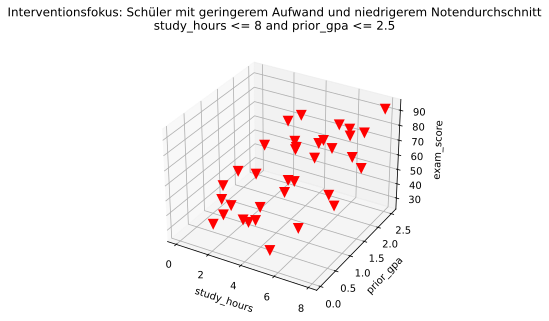

In [8]:
TITEL 'Interventionsfokus: Schüler mit geringerem Aufwand und niedrigerem Notendurchschnitt';
title2 'study_hours <= 8 and prior_gpa <= 2.5';
footnote j=r 'Falllinien lassen jede Markierung auf die Grundflaeche aus Lernstunden und GPA fallen ';

PROZEDUR g3d DATEN=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   WO study_hours <= 8 UND prior_gpa <= 2.5;
   BEZEICHNUNG study_hours = 'Wöchentliche Lernstunden'
         prior_gpa   = 'Vorheriger Notendurchschnitt'
         exam_score  = 'Prüfungsergebnis';
AUSFÜHREN;
QUIT;

## Interpretation der Ergebnisse

Die **Antwortfläche** (Schritte 2–4) zeigt einen klaren, sättigenden Grat. Über das
99-Zellen-Gitter reicht das vorhergesagte Ergebnis von etwa 26 (null Lernstunden, null
Notendurchschnitt) bis etwa 99 (die Ecke mit hohen Stunden und hohem Notendurchschnitt),
mit einem gitterweiten Mittelwert nahe 70. Entlang der Lernstunden-Achse steigen die
Ergebnisse steil von 0 auf etwa 10 Stunden und flachen dann ab, da zusätzliche Stunden
abnehmende Erträge bringen; entlang der Notendurchschnitt-Achse verschiebt der vorherige
Leistungsstand die gesamte Fläche nach oben. Der Interaktionsterm macht den Ertrag der
Lernstunden für stärkere Schüler etwas steiler, weshalb sich die Fläche zu ihrer
entferntesten Ecke neigt, statt als flache Ebene anzusteigen.

Die **Schülerpanels** (Schritte 6–7) bestätigen, dass das Modell für Individuen gilt. Die
Kohorte von 100 teilt sich in 20 *Auszeichnung*, 47 *Bestanden* und 33 *Gefährdet*. In den
Stufenpanels sitzen die 20 grünen *Auszeichnung*-Rauten — jede mit 85 Punkten oder mehr —
bei einem Notendurchschnitt von 2,2 oder höher und mindestens etwa 6 wöchentlichen
Lernstunden, gebündelt in der oberen rechten Ecke der Bodenebene. Die 33 roten
*Gefährdet*-Markierungen konzentrieren sich in der Region mit geringem Aufwand und
niedrigem Notendurchschnitt, genau im Tal der Fläche. Die Aufteilung nach Kohorte zeigt,
dass die Verteilungen von Fall (41 Schüler) und Spring (59 Schüler) insgesamt ähnlich sind,
was darauf hindeutet, dass die Ergebnisse eher von den beiden Faktoren als vom
Einschreibungszeitpunkt bestimmt werden.

Die **mit WHERE gefilterte Ansicht** (Schritt 8) isoliert die Interventionspopulation: die
35 Schüler mit 8 oder weniger Lernstunden und einem Notendurchschnitt von 2,5 oder darunter.
Zweiundzwanzig sind bereits *Gefährdet*, und nur einer erreicht *Auszeichnung*. Innerhalb
dieser Ecke steigen die realisierten Ergebnisse mit den Lernstunden noch sichtbar an — ein
konkretes, visuelles Argument dafür, dass moderate Erhöhungen der strukturierten Lernzeit
den größten Grenznutzen genau dort bieten, wo er am meisten gebraucht wird.

Zusammengenommen verwandelt PROC G3D ein Zweifaktoren-Interaktionsmodell in ein
intuitives, entscheidungsreifes Bild für ein Bildungsprogramm: wo die Ergebnisobergrenze
liegt, wer dahinter zurückbleibt und wo Förderaufwand sich am meisten auszahlt.

> **Implementierungshinweis.** SAS/GRAPH erlaubt es auch, mit einer einzigen
> SCATTER-Anweisung jede Markierung anhand von Variablen pro Beobachtung einzufärben und zu
> formen (`COLOR=<charvar>`, `SHAPE=<charvar>`). Diese Form pro Beobachtung wird in dieser
> Engine noch nicht gerendert, daher zeichnet dieses Notebook stattdessen ein Panel pro
> Stufe mit literaler Farbe — eine gleichwertige, voll funktionsfähige Darstellung. Die
> Lücke wird durch den gebankten Regressionstest
> `tests/401000_nb_g3d_scatter_color_variable_unrendered` nachverfolgt.